# 4. Exponential Decay

## Introduction
In Chapter 4, we explored the concept of exponential decay. In particular, we demonstrated that this deterministic behavior emerges from a stochastic process in which every individual in a population has a constant propensity for dying, independent of age and time.

In this notebook, we carry out numerous simulations to verify this result. The core of the simulation is a matrix with $M$ rows and $N$ columns. The rows represent time points separated by constant intervals, while the columns correspond to distinct individuals. Matrix entries take values of 0 or 1, denoting the state of the corresponding individual at a given time (0: dead; 1: alive).

Initially (at row 0), all individuals are alive. At each consecutive time step, the state of every living individual is randomly updated: with probability $p$, it dies (becomes 0), and with probability $1-p$, it remains alive (stays 1).

Summing the population matrix across columns (row sums) yields a vector representing the number of living individuals at each time step. Conversely, summing the matrix down rows (column sums) produces a vector representing the lifespan of each individual in the population.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, norm

## Simulation routine

In [2]:
def simulation(N0, M, p):
    S = np.zeros((M, N0))
    S[0,:] = np.ones(N0)
    for i in range(1, M):
        S[i, :] = S[i-1, :]
        aux = np.random.random(N0)
        idx = np.where(aux < p)[0]
        S[i, idx] = 0
    return S

## Simulation results

In [12]:
N0 = 10000
M = 10000
p = .002

S = simulation(N0, M, p)

N = np.sum(S, axis=1)
A = np.sum(S, axis=0)

# Population evolution

Comparison of the simulation results with the exponential decay function $N(t) = N_0 e^{-pt}$."


Text(0, 0.5, 'Population ($N$)')

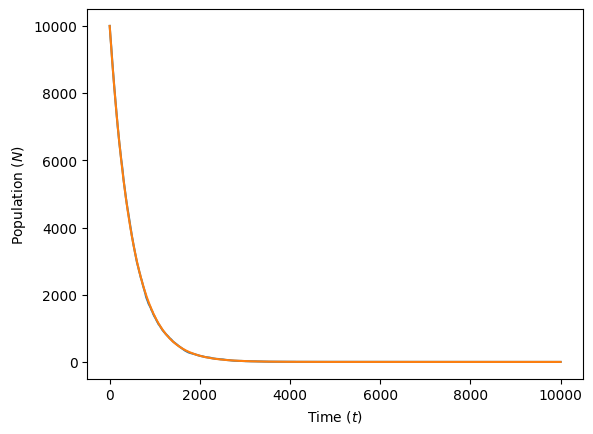

In [13]:
plt.plot(N)
plt.plot(np.arange(M), N0*np.exp(-p*np.arange(M)))
plt.xlabel(r"Time ($t$)")
plt.ylabel(r"Population ($N$)")

## Semilog plot

Although the simulation results and the exponential decay function appear to overlap in the previous plot, a logarithmic vertical axis reveals distinct behaviors. While the agreement is excellent for large population sizes (greater than a few hundred), significant discrepancies emerge at small values, highlighting the stochastic nature of the simulation. Specifically, whereas the exponential decay function asymptotically approaches zero, the simulated population becomes extinct in finite time. The strong agreement observed at large population values illustrates the law of large numbers.

Text(0, 0.5, 'Population ($N$)')

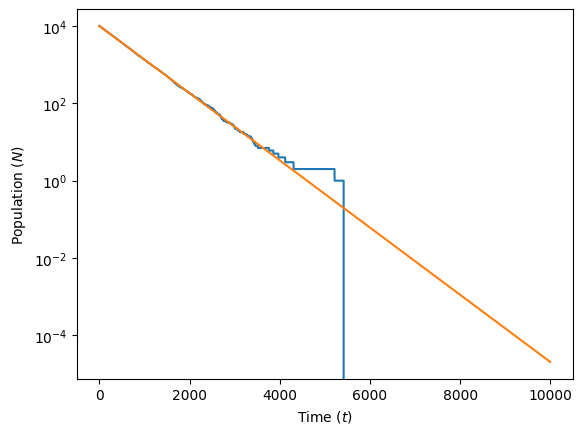

In [14]:
plt.semilogy(N)
plt.semilogy(np.arange(M), N0*np.exp(-p*np.arange(M)))
plt.xlabel(r"Time ($t$)")
plt.ylabel(r"Population ($N$)")

## Individual lifestan statistics

Observe tha the probability density function of the individual lifespan is exponential. 

Text(0.5, 1.0, 'Avg. Lifespan. Theor- = 500.0 Simu. = 500.6681')

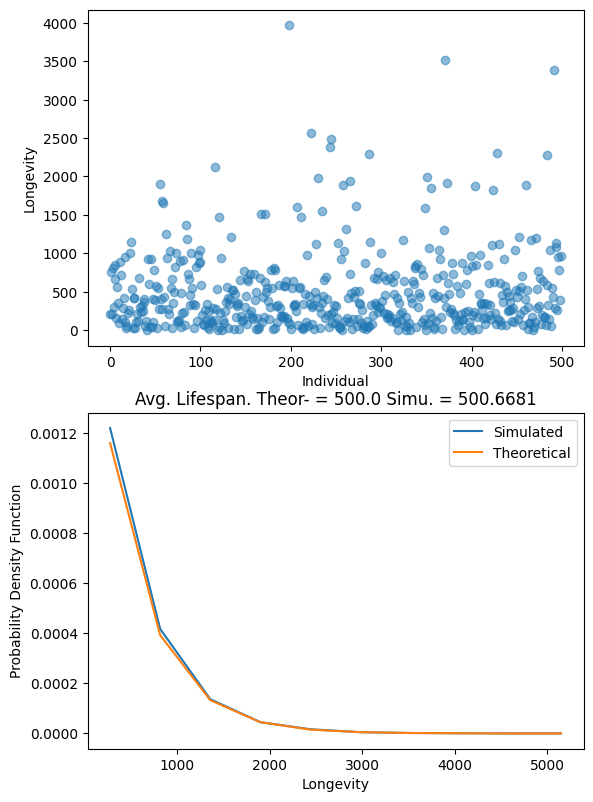

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6.4, 9.6))

ax[0].scatter(range(500), A[:500], alpha=0.5)
ax[0].set_xlabel("Individual")
ax[0].set_ylabel("Longevity")

freqs, bins = np.histogram(A)
pdf = freqs / sum(freqs) / np.diff(bins)
mid_bins = (bins[1:] + bins[:-1])/2

ax[1].plot(mid_bins, pdf, label="Simulated")
ax[1].plot(mid_bins, p*np.exp(-p*mid_bins), label="Theoretical")
ax[1].set_xlabel("Longevity")
ax[1].set_ylabel("Probability Density Function")
ax[1].legend()
ax[1].set_title("Avg. Lifespan. Theor- = " + str(1/p)+", Simu. = " + str(np.mean(A)))

## Second simulation strategy

Given that individual lifespans follow the exponential distribution $p e^{-pt}$, we can simulate the evolution of an initial population undergoing exponential decay by randomly generating a lifespan for each individual from this distribution. We can then determine the number of individuals remaining alive at any given time. The following routine implements this approach.

In [19]:
def simulation2(N0, M, p):
    ages = expon.rvs(scale=1/p, size=N0)
    N = np.zeros(M)
    for i in range(M):
        N[i]=len(np.where(ages > i)[0])
    return(N)

## Law of large numbers

To corroborate the law of large numbers, we simulate the stochastic evolution of 10,000 independent populations and plot the individual trajectories alongside the ensemble average. Observe that the theoretical exponential decay corresponds to the average behavior of the large number of simulations. Furthermore, notice that individual simulations closely track this average behavior when the population size is large.

Text(0, 0.5, 'Population ($N$)')

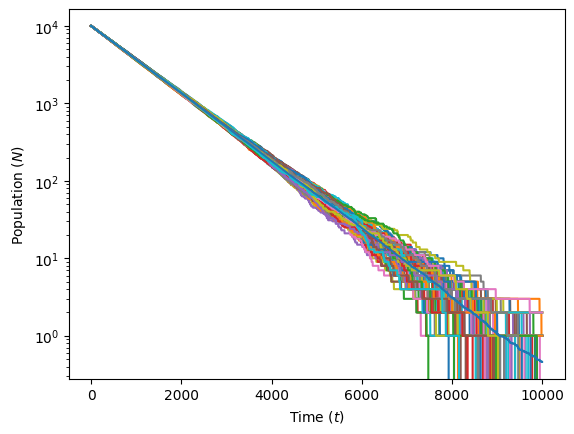

In [21]:
fig, ax = plt.subplots()
N0 = 10000
M = 10000
p = .001

Navg = np.zeros(M)
for i in range(100):
    N = simulation2(N0, M, p)
    ax.semilogy(N)
    Navg = Navg + N
Navg = Navg / 100

ax.semilogy(Navg)
ax.set_xlabel(r"Time ($t$)")
ax.set_ylabel(r"Population ($N$)")

## Normal distribution of lifespans

Next, we introduce a routine where individual lifespans are assumed to follow a normal distribution instead of an exponential one, while maintaining the same mean value.

In [2]:
def simulation3(N0, M, p):
    ages = norm.rvs(loc=1/p, scale=1/p, size=N0)
    N = np.zeros(M)
    for i in range(M):
        N[i]=len(np.where(ages > i)[0])
    return(N)

## Is the decay exponential?

The simulation does not reproduce exponential decay. This illustrates that random death events at the individual level do not necessarily produce exponential decay for the aggregate population; the specific distribution of lifespans determines the outcome.

Text(0, 0.5, 'Population ($N$)')

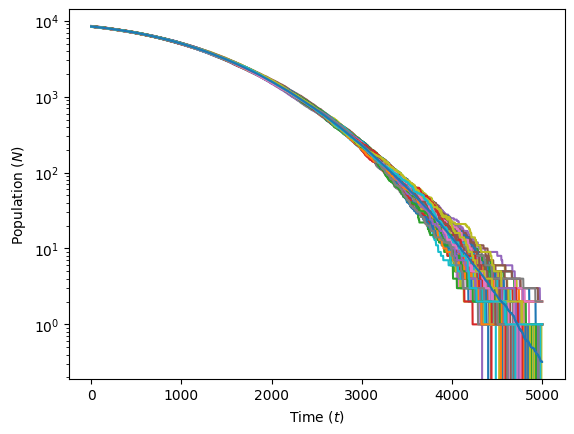

In [3]:
N0 = 10000
M = 5000
p = .001

Navg = np.zeros(M)
for i in range(100):
    N = simulation3(N0, M, p)
    plt.semilogy(N)
    Navg += N
Navg /= 100

plt.semilogy(Navg)
plt.xlabel(r"Time ($t$)")
plt.ylabel(r"Population ($N$)")